## **Support Vector Classifier Implimentation**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns


In [64]:
## First we create a synthetic dataset
from sklearn.datasets import make_classification
X,y = make_classification(n_samples=1000,
                          n_features=2,
                          n_classes=2,
                          n_clusters_per_class=1,
                          n_redundant=0,
                          random_state=42
                          
                          )

In [65]:
X[:5]

array([[ 0.60103418,  1.5353525 ],
       [ 0.75594526, -1.1723519 ],
       [ 1.35447877, -0.94852841],
       [ 3.1030897 ,  0.23348484],
       [ 0.75317779,  0.78751427]])

In [66]:
y[:5]

array([1, 0, 0, 0, 1])

<Axes: xlabel='0', ylabel='1'>

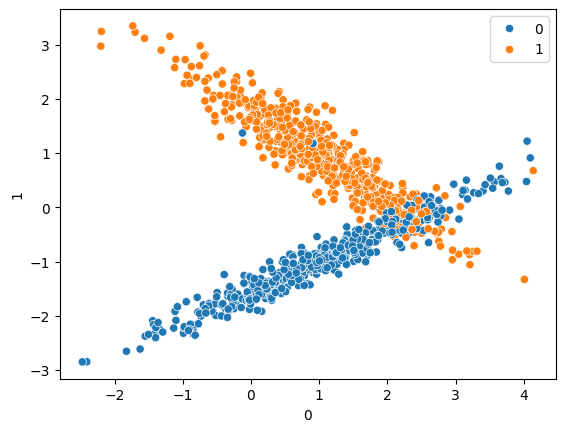

In [67]:
## Now we plot the dataset 
sns.scatterplot(x=pd.DataFrame(X)[0],y=pd.DataFrame(X)[1],hue=y)

### **Applying SVC**

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split 


In [ ]:

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2,random_state=42)

In [70]:
X_train

array([[ 1.469818  ,  0.5287991 ],
       [ 0.69413954, -1.06876393],
       [ 1.75247488,  0.1976829 ],
       ...,
       [ 1.08621999, -0.74806738],
       [ 1.64989181, -0.71885362],
       [ 4.1387154 ,  0.67530512]], shape=(800, 2))

In [71]:
y_train[:5]

array([1, 0, 1, 0, 0])

In [72]:
svc_linear =SVC(kernel='linear') 

In [73]:
svc_linear.fit(X_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [74]:
### prediction
y_pred1 = svc_linear.predict(X_test)

In [101]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score

In [76]:
print(confusion_matrix(y_test,y_pred1))
print(classification_report(y_test,y_pred1))

[[103   1]
 [ 14  82]]
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       104
           1       0.99      0.85      0.92        96

    accuracy                           0.93       200
   macro avg       0.93      0.92      0.92       200
weighted avg       0.93      0.93      0.92       200



### `As the data is linearly separable that's why it is giving good measure`

## **Now we make the data Non-Linear then apply all kernel one-by-one**

In [91]:
## First we create a synthetic dataset
from sklearn.datasets import make_classification
X,y = make_classification(n_samples=1000,
                          n_features=2,
                          n_classes=2,
                          n_clusters_per_class=2,
                          n_redundant=0,
                          random_state=42
                          
                          )

<Axes: xlabel='0', ylabel='1'>

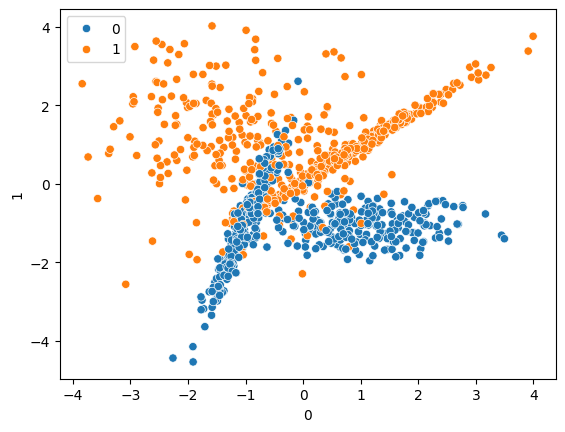

In [92]:

## Now we plot the dataset 
sns.scatterplot(x=pd.DataFrame(X)[0],y=pd.DataFrame(X)[1],hue=y)


In [93]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split 
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2,random_state=42)

In [94]:
svc_linear = SVC(kernel='linear')
svc_linear.fit(X_train,y_train)
y_pred1 = svc_linear.predict(X_test)

print(confusion_matrix(y_test,y_pred1))
print(classification_report(y_test,y_pred1))

[[89 12]
 [12 87]]
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       101
           1       0.88      0.88      0.88        99

    accuracy                           0.88       200
   macro avg       0.88      0.88      0.88       200
weighted avg       0.88      0.88      0.88       200



`As we increases the cluster per class then accuracy decrease from 93% to 88%`

### **kernel = polynomial**

In [ ]:

svc_polynomial = SVC(kernel='poly')
svc_polynomial.fit(X_train,y_train)
y_pred2 = svc_polynomial.predict(X_test)

print(confusion_matrix(y_test,y_pred2))
print(classification_report(y_test,y_pred2))

[[83 18]
 [ 6 93]]
              precision    recall  f1-score   support

           0       0.93      0.82      0.87       101
           1       0.84      0.94      0.89        99

    accuracy                           0.88       200
   macro avg       0.89      0.88      0.88       200
weighted avg       0.89      0.88      0.88       200



`Ploynomial transformation not increases the accuracy also`

### **kernel = rbf**

In [96]:

svc_rbf = SVC(kernel='rbf')
svc_rbf.fit(X_train,y_train)
y_pred3 = svc_rbf.predict(X_test)

print(confusion_matrix(y_test,y_pred3))
print(classification_report(y_test,y_pred3))

[[95  6]
 [14 85]]
              precision    recall  f1-score   support

           0       0.87      0.94      0.90       101
           1       0.93      0.86      0.89        99

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.90      0.90      0.90       200



`As you can see over here as we apply the rbf transformation then it imporve the accuracy from 88% to 90%`

### **kernel=sigmoid**

In [97]:

svc_sigmoid = SVC(kernel='sigmoid')
svc_sigmoid.fit(X_train,y_train)
y_pred4 = svc_sigmoid.predict(X_test)

print(confusion_matrix(y_test,y_pred4))
print(classification_report(y_test,y_pred4))

[[74 27]
 [15 84]]
              precision    recall  f1-score   support

           0       0.83      0.73      0.78       101
           1       0.76      0.85      0.80        99

    accuracy                           0.79       200
   macro avg       0.79      0.79      0.79       200
weighted avg       0.79      0.79      0.79       200



`after applying sigmoid transformation we are getting very very poor result`

In [ ]:
SVC()

### **Now we hyperparameter tune the model having rbf transformation because it giving best accuracy on non-linear data**

In [112]:
params = {
    'gamma':[1,0.1,0.001,0.0001,],
    'decision_function_shape': ['ovo'],
    'degree':[2,3,4,5],
    'kernel':['rbf'],
    
}

In [113]:
from sklearn.model_selection import GridSearchCV

In [114]:
grid = GridSearchCV(SVC(),
                    param_grid=params,
                    scoring=accuracy_score,
                    n_jobs=-1,
                    cv=5,
                    refit=True,
                    verbose=3
                    
                    )

In [115]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


d:\University\DataScience\Specialization\venv\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'decision_function_shape': ['ovo'], 'degree': [2, 3, ...], 'gamma': [1, 0.1, ...], 'kernel': ['rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",<function acc...002185509CF40>
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displa

In [116]:
y_pred5 = grid.predict(X_test)

In [117]:
print(confusion_matrix(y_test,y_pred5))
print(classification_report(y_test,y_pred5))

[[97  4]
 [10 89]]
              precision    recall  f1-score   support

           0       0.91      0.96      0.93       101
           1       0.96      0.90      0.93        99

    accuracy                           0.93       200
   macro avg       0.93      0.93      0.93       200
weighted avg       0.93      0.93      0.93       200



`As you can see the hyperparameter tuning has increases the accuracy from 90% to 93%`

In [118]:
grid.best_params_

{'decision_function_shape': 'ovo', 'degree': 2, 'gamma': 1, 'kernel': 'rbf'}

In [121]:
grid.param_grid

{'gamma': [1, 0.1, 0.001, 0.0001],
 'decision_function_shape': ['ovo'],
 'degree': [2, 3, 4, 5],
 'kernel': ['rbf']}